
# CS 171 / EE 142 Problem Set 4
# Due Friday, May 22, 2026

<div style="color: #000000;background-color: #FFEEFF">
In this problem set, you are to implement a three-layer (3 layers of weights, 2 hidden layers of units) neural network for binary classification.  All non-linearities are to be hyperbolic tangents (tanh).

Details are given below.  *Please read the **entire** notebook carefully before proceeding.*

You need to both fill in the necesary code, **and** answer the question at the bottom.</div>

### Enter your information below:

<div style="color: #000000;background-color: #EEEEFF">
    Your Name (submitter): <br> Kaushik Vada
Your student ID (submitter): <br> 862441522
    
<b>By submitting this notebook, I assert that the work below is my own work, completed for this course.  Except where explicitly cited, none of the portions of this notebook are duplicated from anyone else's work or my own previous work.</b>
</div>

<div class="alert alert-success">
    <font size=+2>Total Problem Set Grading</font> (to be completed by grader)<br>
    Total Points: /20<br>
    Late Days Used on this Assignment: <br>
    Total Late Days Used: <br>
</div>

In [1]:
# Below are the only imports that are necessary (or allowed)
import numpy as np
import h5py 
import matplotlib.pyplot as plt
import time
from IPython import display

## Data

<div style="color: #000000;background-color: #FFEEFF">
We will be using a USPS digit dataset (provided in the file uspsall73.mat).
It has 16-by-16 grayscale images of each of the 10 different hand-written digits
However, we will load only two of the digit classes to use as the two classes in
binary classification (the sevens and the nines).  The code below already z-score 
normalizes the data for you -- an important first step!
<p>
    <p>
    Note:  digit recognition typically uses larger datasets (more than 1000 images per class) and often with higher resolution images.  We are using lower resolution images (fewer features) and small training and validation data sets (fewer examples) to speed up training time.  You may choose to further reduce the training data set during your own debugging to speed things up.  Be sure to remove that reduction and rerun the notebook with the full dataset once you have finished debugging.
</div>

In [2]:
# function to load two of the 10 classes (c1 is for Y=-1 and c2 is for Y=+1)
def loaddigitdata(c1,c2,m):
    f = h5py.File('/usr/local/cs171/uspsall73.mat','r') 
    data = f.get('data') 
    data = np.array(data).astype(float)
    X = np.concatenate((data[c1,:,:],data[c2,:,:]))
    Y = np.concatenate((-np.ones((data.shape[1])),np.ones((data.shape[1]))))
    
    rs = np.random.RandomState(seed=132857) # setting seed so that dataset is consistent
    p = rs.permutation(X.shape[0])
    X = X[p] # this and next line make copies, but that's okay given how small our dataset is
    Y = Y[p]
    
    trainX = X[0:m,:] # use the first m (after shuffling) for training
    trainY = Y[0:m,np.newaxis]
    validX = X[m:,:] # use the rest for validation
    validY = Y[m:,np.newaxis]
    return (trainX,trainY,validX,validY)

In [3]:
# load the data, to differentiate between 7s and 9s
# we will use on 1100 examples for training (50% of the data) and the other half for hold-out validation
(trainX,trainY,validX,validY) = loaddigitdata(6,8,1100)
means = trainX.mean(axis=0)
stddevs = trainX.std(axis=0)
stddevs[stddevs<1e-6] = 1.0
trainX = (trainX-means)/stddevs # z-score normalization
validX = (validX-means)/stddevs # apply same transformation to validation set

<div style="color: #000000;background-color: #FFFFEE">
    <font size=+2>Question 1:</font> <font size=+1>(17 points)</font>
This is the main portion of the assignment.  Read the text below carefully.
</div>

<div class="alert alert-success">
    <font size=+1>Grading</font> (to be completed by grader)<br>
    Score: /17<br>
</div>

### WRITE `nneval` and `trainneuralnet`

<div style="color: #000000;background-color: #FFFFEE">

Note that the target $Y$ values are +1 and -1.  The internal nodes should all use the hyperbolic tangent (np.tanh) as the nonlinearity.

You need to write the two functions below (plus any more you would like to add to help): `nneval` and `trainneuralnet`.  The first takes an array/matrix of X vectors and the weights from a neural network and returns a vector of discriminant values (should be numbers between -infinity and +infinity).  The second takes a data set (Xs and Ys), the number of hidden units, and the lambda value (for l2-regularization), and returns the weights, Wts.  Wts[0] are the weights from the input to the first hidden layer.  Wts[1] are the weights from the first hidden layer to the second hidden layer.  Wts[2] are the weights from the second hidden layer to the output.

A few notes:
- **Starting Weights**: The code supplied randomly selects the weights near zero.  Technically, this is called Xavier initialization (see https://ai.stackexchange.com/questions/42975/what-are-the-techniques-used-to-initialize-weights-for-neural-networks) for an interactive explanation.  But for the purposes of the assignment, you can just accept this is a good way to initialize neural network weights.
- **Offset Terms**: Each layer should have an "offset" or "intercept" unit (to supply a 1 to the next layer), except the output layer.
- **Batch Updates**: For a problem this small, use batch updates.  That is, the step is based on the sum of the gradients for each data point in the training set.
- **Step Size**: https://www.digitalocean.com/community/tutorials/intro-to-optimization-momentum-rmsprop-adam describes a number of methods to adaptively control $\eta$ for fast convergence.  You don't need to understand any of them; however, without them, convergence to good solutions on this problem can be quite slow.  Therefore, *use RMSprop*: the code below has a simple version of RMSprop that is sufficient for this assignment.  You need to supply the code that calculates `sumofgrad2` which should be the sum of the square of each element of the *full* gradient (the squared length of the gradient including the regularization term).  (for debugging, feel free to use a constant $\eta$ initially). 
- **Stopping Criterion**: To determine when to stop, check the loss (full loss, including the regularization term) function every 100 iterations.  If it has not improved by at least $10^{-5}$ over those 100 iterations, stop.
- **Regularization**: You should penalize (from the regularization) all of the weights, even those coming out of offset units.  While it makes sense sometimes not to penalize the ones for the constant $1$ units, you'll find this easier if you just penalize them all.

Tips that might help:
- Display the loss function's value every 100-1000 iterations (or so).  It should be getting smaller.  If not, your gradient is not pointing in the right direction.
    - The most common mistake is to subtly have the wrong loss function or the wrong gradient.  The gradient is the gradient of the entire loss function, including the regularization term.  A small mistake will cause the loss function to initially get better, but then to get worse.
- The smaller $\lambda$ is and the more units, the more difficult (longer) the optimization will be.
- Write a function to do forward propagation and one to do backward propagation.  Write a function to evaluate the loss function.  In general, break things up to keep things straight.
- Processing the entire batch at once is more efficient in numpy than using a loop over the examples.  Use numpy broadcasting to avoid loops where possible.
- Create a small dataset from the examples in class.  Check that you get the same results for forward propagation.  Check you get the same results for backward propagation.  Check that you get the same results for the gradients.
- You can reduce the stopping criterion (from $10^{-5}$ to something closer to 1) temporarily to make it finish faster.
</div>

In [4]:
### FEEL FREE TO ADD HELPER FUNCTIONS

def addones(Z):
    return np.hstack((np.ones((Z.shape[0],1)),Z))

def sigmoid(z): # written via tanh so it doesn't overflow for large |z|
    return 0.5*(1+np.tanh(0.5*z))

# Forward pass.  Returns the post-activation values at each layer and the output f.
# A0/A1/A2 already have the offset (1) column prepended so each feeds the next layer.
def forwardprop(X,Wts):
    W1,W2,W3 = Wts
    A0 = addones(X)
    A1 = addones(np.tanh(A0@W1.T))
    A2 = addones(np.tanh(A1@W2.T))
    f = A2@W3.T
    return A0,A1,A2,f

# Full regularized loss: logistic loss -ln(sigmoid(y*f)) summed over the examples,
# plus lam times the sum of squares of every weight (offset weights included).
def nnloss(X,Y,Wts,lam):
    f = forwardprop(X,Wts)[3]
    dataloss = np.logaddexp(0,-Y*f).sum() # = sum of -ln(sigmoid(y*f)), computed stably
    reg = lam*sum((W**2).sum() for W in Wts)
    return dataloss+reg

# Gradient of nnloss with respect to each weight matrix (back propagation).
def nngrad(X,Y,Wts,lam):
    W1,W2,W3 = Wts
    A0,A1,A2,f = forwardprop(X,Wts)
    dZ3 = -Y*sigmoid(-Y*f)                 # dL/df for the logistic loss
    dZ2 = (1-A2[:,1:]**2)*(dZ3@W3)[:,1:]   # back through W3, drop offset col, times tanh'
    dZ1 = (1-A1[:,1:]**2)*(dZ2@W2)[:,1:]
    gW1 = dZ1.T@A0 + 2*lam*W1              # data-term gradient plus the regularizer's 2*lam*W
    gW2 = dZ2.T@A1 + 2*lam*W2
    gW3 = dZ3.T@A2 + 2*lam*W3
    return [gW1,gW2,gW3]

## Wts is a list (length 3) of the Weight matrices
## X is an m-by-n matrix of m examples
## returns m-length vector of the discriminant, f(x), for each example
def nneval(X,Wts):
    return forwardprop(X,Wts)[3]
    
# Your functions need only work for neural networks of exactly 3 layers of weights
# This training function has a single scalar parameter, nhid, to indicate the number of
# hidden units.  This is the number in the first hidden layer.  The second hidden layer will have sqrt this number
def trainneuralnet(X,Y,nhid,lam):
    # The number of examples (m) and number of input dimensions (n) of the input data
    (m,n) = X.shape

    nhid2 = int(np.ceil(np.sqrt(nhid))) 
    W1 = (np.random.rand(nhid,n+1)*2-1)*np.sqrt(6.0/(n+nhid+1)) # weights to each hidden unit from the inputs (plus the added offset unit)
    W2 = (np.random.rand(nhid2,nhid+1)*2-1)*np.sqrt(6.0/(nhid+nhid//2+1))
    W3 = (np.random.rand(1,nhid2+1)*2-1)*np.sqrt(6.0/(nhid//2+2)) # weights to the single output unit from the hidden units (plus the offset unit)
    W1[:,0] = 0 # good initializations for the constant terms
    W2[:,0] = 0 
    W3[:,0] = 0 
    
    Wts = [W1,W2,W3] # I put them together in a list, but you can use a tuple too

    #keep this:
    Eg2=1
    
    done = False
    it = 0
    lastloss = nnloss(X,Y,Wts,lam)
    while not done:

        grads = nngrad(X,Y,Wts,lam)
        sumofgrad2 = sum((g**2).sum() for g in grads)

        # when you need "eta" (the step size), do this after you have already
        # calculated the gradient (but before you take a step):
        # [where "sumofgrad2" is the sum of the squares of each element of the gradient
        #  that is, you square *all* of the gradient values and then add them all together]
        # [recall that this is the gradient of the full loss function that includes every
        #  example *and* the regularizer term]
        Eg2 = 0.9*Eg2 + 0.1*sumofgrad2
        eta = 0.01/(np.sqrt((1e-10+Eg2)))

        for k in range(3):
            Wts[k] = Wts[k] - eta*grads[k]

        it += 1
        if it%100==0: # every 100 steps, stop once the loss has basically stopped dropping
            curloss = nnloss(X,Y,Wts,lam)
            if lastloss-curloss < 1e-5:
                done = True
            lastloss = curloss
                
    return Wts 


In [5]:
%%time
# Use this cell (or others you add) to check your network
# I would debug on simple examples you create yourself (trying to understand what happens with
#  the full 256-dimensional data is hard)

#an example of training on the USPS data with 16/8 hidden units and lambda=0.00001, takes about 1500 iterations and about 20 seconds for the solutions
Wts = trainneuralnet(trainX,trainY,32,1e-3)


CPU times: user 2.14 s, sys: 22.1 ms, total: 2.16 s
Wall time: 2.17 s


## Performance plot
<div class="alert alert-info">
The code below will plot your algorithm's error rate on this data set for various regularization strengths and numbers of hidden units.

Make sure your code works for this plot.

My code runs in about 20-25 minutes (to produce the full plot below)
</div>

In [6]:
## Code added to do logistic regression, just for a comparison
def learnlogreg_sklearn(X,Y,regstr=0.0,penalizeb=False):
    X = addones(X)
    Y = Y[:,0]
    from sklearn.linear_model import LogisticRegression as lr
    if regstr==0.0:
        pen = None
        C = np.inf
    else:
        pen = 'l2'
        C = 2.0/regstr # ???

    Y = (Y>0.5).astype(int)
    if penalizeb:
        lrres = lr(tol=1e-6,max_iter=100000,penalty=pen,C=C,
                   fit_intercept=False,
                   solver='newton-cg').fit(X,Y)
        w = lrres.coef_[0,:]
    else:
        lrres = lr(tol=1e-6,max_iter=100000,penalty=pen,C=C,
                   fit_intercept=True,
                   solver='newton-cg').fit(X[:,1:],Y)
        w = np.hstack((lrres.intercept_,lrres.coef_[0,:]))
    return w

def predictlogreg(X,w):
    return addones(X)@w

In [7]:
# Code to update the plot as new results are generated
def setupfig():
    f = plt.figure()
    f.set_size_inches(8,8)
    ax = f.add_subplot(111)
    plt.ion()
    f.canvas.draw()
    return (f,ax)

def plotit(lams,nhiddens,erates,f,ax):
    ax.clear()
    for i in range(nhiddens.shape[0]):
        ax.plot(lams,erates[:,i],'*-')
    ax.set_yscale('log',subs=[1,2,3,4,5,6,7,8,9])
    ax.set_yticks([0.03,0.01])
    ax.set_xscale('log')
    f.canvas.draw()
    ax.set_xlabel('lambda')
    ax.set_ylabel('validation error rate')
    ax.legend([(('# hidden units = '+str(x)+','+str(int(np.ceil(np.sqrt(x))))) if x>0 else 'logistic regression') for x in nhiddens])
    display.display(f)
    display.clear_output(wait=True)
    

CPU times: user 4min 58s, sys: 1.98 s, total: 5min
Wall time: 5min 1s


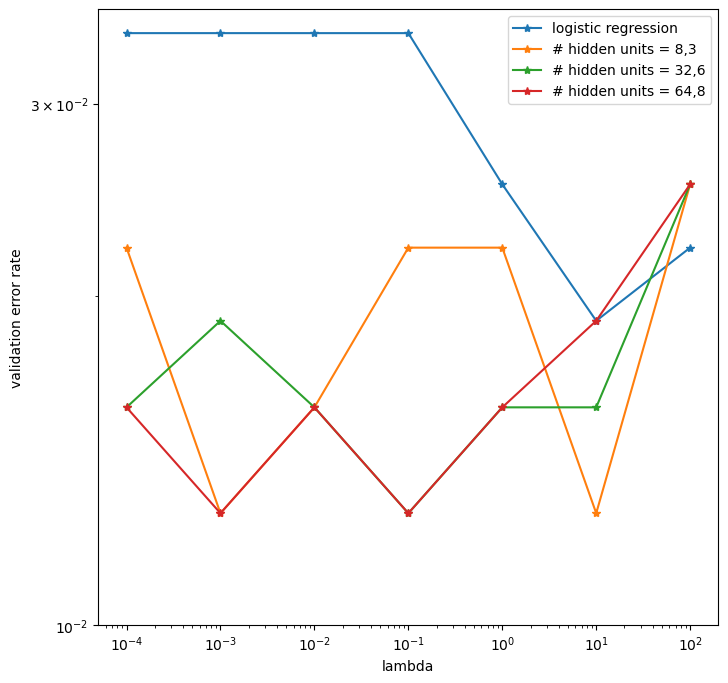

In [8]:
%%time
def errorrate(Y,predy):
    predy = np.sign(predy)
    return (predy!=Y).mean()
    
def multirestart(trainX,trainY,nhid,lam,ntries):
    besterrsc = 2.0
    for i in range(ntries):
        Wts = trainneuralnet(trainX,trainY,nhid,lam)
        errsc = errorrate(trainY,nneval(trainX,Wts))
        if errsc<besterrsc:
            returnWts = Wts
            besterrsc = errsc
    return returnWts

nhiddens = np.array([0,8,32,64])
lams = np.logspace(-4,2,7)
erates = np.empty([lams.shape[0],nhiddens.shape[0]])
erates[:,:] = np.nan

(f,ax) = setupfig()
    
for ni, nhid in enumerate(nhiddens):
    for li, lam in reversed(list(enumerate(lams))):
        if nhid==0:
            w = learnlogreg_sklearn(trainX,trainY,lam)
            predy = predictlogreg(validX,w)[:,np.newaxis]
        else:
            Wts = multirestart(trainX,trainY,nhid,lam,4) 
            #Wts = trainneuralnet(trainX,trainY,nhid,lam)
            predy = nneval(validX,Wts)
        erates[li,ni] = errorrate(validY,predy)
        
        plotit(lams,nhiddens,erates,f,ax)

<div style="color: #000000;background-color: #FFFFEE">
    <font size=+2>Question 2:</font> <font size=+1>(3 points)</font>
How does changing the number of hidden units change the validation result?

How does the optimal regularization strength relate to the number of hidden units?  Why might that be the case?
</div>
<div class="alert alert-success">
    <font size=+1>Grading</font> (to be completed by grader)<br>
    Score: /3<br>
</div>

Generally, the more units, the better the error rate. 

The best regularization strength is lower for larger number of parameters.  This is a bit surprising, but might be because the regularization term is over more weights with more hidden units.  Therefore, its total strength (before being multiplied by lambda) is already larger with more units.